# Занятие 35. Решающее дерево

**Решающее дерево** (decision tree) — модель, которая принимает решение цепочкой вопросов «да / нет». Каждый вопрос смотрит на один признак и сравнивает его с порогом.

На занятии 33 вы уже видели, что сложная модель без ограничений переобучается. Дерево — яркий пример: оно легко строит нелинейные правила и понятно человеку, но глубокое дерево запоминает шум.

**Сквозной пример:** мини-датасет «подготовка к экзамену» — часы подготовки, часы сна → **сдал / не сдал**. Данные и обученное дерево — в ячейке ниже; все разделы — про них.

**Схема дерева** (упрощённо, до обучения sklearn):

```
              [подготовка ≤ порог?]
                    /        \
                  да         нет
                  /            \
           [сон ≤ порог?]    [сон ≤ порог?]
              /    \            /    \
          не сдал  ...       ...    сдал
```

Сначала разберём **классификацию** на этом примере; критерий для **регрессии** (MSE) — в п. 7.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = pd.DataFrame({
    'подготовка': [1, 2, 3, 4, 5, 6, 7, 8, 4, 6],
    'сон': [5, 8, 6, 7, 5, 8, 6, 9, 9, 4],
})
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0])  # 0 = не сдал, 1 = сдал

tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X, y)
print('Объектов:', len(X), '| признаков:', list(X.columns))
X


Объектов: 10 | признаков: ['подготовка', 'сон']


,подготовка,сон
0,1,5
1,2,8
2,3,6
3,4,7
4,5,5
5,6,8
6,7,6
7,8,9
8,4,9
9,6,4


## 1. Правила «если — то» и устройство дерева

**Определение.** Решающее дерево — набор вложенных правил:

> если признак ≤ порог, то идём **влево** (ответ «да»), иначе **вправо** («нет»); в **листе** — итоговый прогноз.

**Части дерева:**
- **Корень** (root) — первый вопрос.
- **Внутренний узел** — промежуточный вопрос; у него два дочерних узла.
- **Ветвь** — ответ «да» (влево) или «нет» (вправо).
- **Лист** (leaf) — узел без дочерних вопросов; здесь хранится прогноз.

**Пример на сквозном датасете:** «подготовка ≤ 4?» → «сон ≤ 6?» → «не сдал».

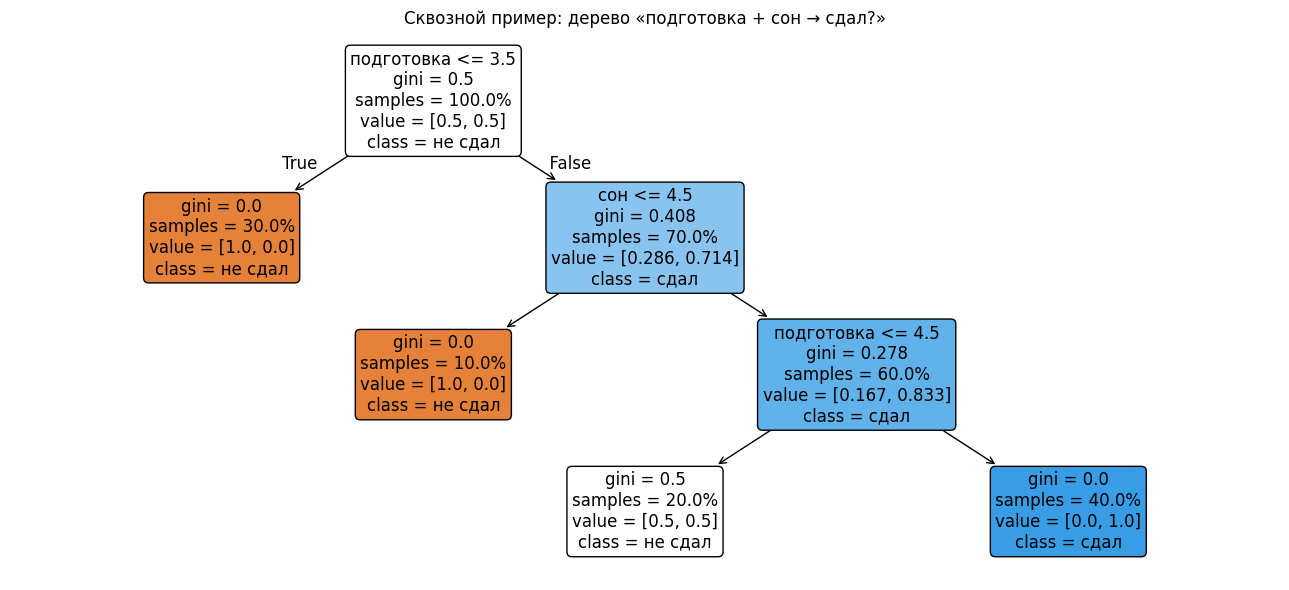

In [32]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=['не сдал', 'сдал'],
    filled=True,
    rounded=True,
    fontsize=12,
    proportion=True,
    ax=ax,
)
ax.set_title('Сквозной пример: дерево «подготовка + сон → сдал?»')
plt.tight_layout()
plt.show()


**Как читать `plot_tree`:** в каждом прямоугольнике:
- **условие** — например, `подготовка <= 3.5` (влево = «да», вправо = «нет»);
- **gini** — неоднородность классов в узле (0 = все одного класса);
- **samples** — сколько учебных объектов попало в узел;
- **value** — сколько объектов каждого класса;
- **class** — прогноз класса в листе.

## 2. Как выбирается признак и порог

**Признак** — столбец, по которому задаётся вопрос (`подготовка` или `сон`).

**Порог** — число $t$ в условии «признак ≤ $t$».

**Неоднородность (impurity)** — насколько в узле смешаны классы. Чистый узел — кандидат в лист; смешанный — кандидат на новый вопрос.

**Как ищет sklearn:** для каждого признака перебираются пороги между соседними **отсортированными** уникальными значениями (часто — середины между ними). Для каждого кандидата считается, насколько улучшится однородность дочерних узлов.

**Критерий** (`criterion` в `DecisionTreeClassifier`) — формула неоднородности: по умолчанию `gini`, альтернатива — `entropy` (п. 5).

Алгоритм **жадный**: на каждом шаге выбирается лучшее **сейчас** разбиение, без оглядки вперёд (полный перебор всех деревьев — NP-полная задача).

## 3. Мера неопределённости Джини (Gini impurity)

**Gini** измеряет, насколько узел «смешанный»:

$$Gini = 1 - \sum_k p_k^2,$$

где $p_k$ — доля класса $k$ среди объектов узла.

| Состав узла | $p_0$, $p_1$ | Gini |
|-------------|--------------|------|
| 4 объекта класса 1 | 0, 1 | 0.0 (чистый) |
| 2+2 | 0.5, 0.5 | 0.5 (максимально смешанный для 2 классов) |
| 3×0 и 1×1 | 0.75, 0.25 | 0.375 |

Gini = 0, если в узле один класс. Чем сильнее смешение, тем Gini больше.

In [16]:
def gini(labels):
    counts = np.bincount(labels)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

for labels in [np.array([1, 1, 1, 1]), np.array([0, 0, 1, 1]), np.array([0, 0, 0, 1])]:
    print(labels, 'Gini =', round(gini(labels), 3))


[1 1 1 1] Gini = 0.0
[0 0 1 1] Gini = 0.5
[0 0 0 1] Gini = 0.375


## 4. Information gain и качество разбиения

После вопроса объекты делятся на **левый** и **правый** дочерний узел. Считают **взвешенный** Gini (больший вклад — у узла с большим числом объектов):

$$Gini_{split}=\frac{n_L}{n}Gini_L+\frac{n_R}{n}Gini_R.$$

**Information gain** — насколько уменьшилась неоднородность:

$$gain = Gini_{parent} - Gini_{split}.$$

Алгоритм выбирает пару (признак, порог) с **максимальным** gain.

**Ручной пример.** Родитель: 6 объектов `[0,0,0,1,1,1]`, $Gini=0.5$.
- A: слева `[0,0,0]`, справа `[1,1,1]` → оба листа чистые → $gain=0.5$.
- B: слева `[0,0]`, справа `[0,1,1,1]` → смешение справа → gain меньше.

In [17]:
parent = np.array([0, 0, 0, 1, 1, 1])
splits = {
    'A: классы разделены': (np.array([0, 0, 0]), np.array([1, 1, 1])),
    'B: классы смешаны': (np.array([0, 0]), np.array([0, 1, 1, 1])),
}

def weighted_gini(left, right):
    n = len(left) + len(right)
    return (len(left) * gini(left) + len(right) * gini(right)) / n

parent_g = gini(parent)
for name, (L, R) in splits.items():
    split_g = weighted_gini(L, R)
    print(name, 'Gini_split =', round(split_g, 3), 'gain =', round(parent_g - split_g, 3))


A: классы разделены Gini_split = 0.0 gain = 0.5
B: классы смешаны Gini_split = 0.25 gain = 0.25


## 5. Энтропия *

**Энтропия** — альтернативный критерий неоднородности:

$$Entropy = -\sum_k p_k \log_2 p_k.$$

Смысл тот же: в чистом узле энтропия 0, при смешении растёт. Хороший вопрос уменьшает энтропию (аналог gain для Gini).

| Узел | Gini | Entropy |
|------|------|---------|
| [0,0,0,0] | 0.000 | 0.000 |
| [0,0,1,1] | 0.500 | 1.000 |
| [0,0,0,1] | 0.375 | 0.811 |

В sklearn: `DecisionTreeClassifier(criterion='entropy')`. На практике Gini и entropy часто дают похожие деревья; важнее ограничить глубину (п. 11).

## 6. Рекурсивное построение и остановка

**Рекурсия:** после первого вопроса алгоритм обрабатывает левую и правую группы **отдельно** — снова ищет лучший (признак, порог).

**Когда построение прекращается:**
- узел **чистый** (один класс);
- объектов **мало** (`min_samples_split`, `min_samples_leaf`);
- достигнута **максимальная глубина** (`max_depth`).

Дерево строится **сверху вниз**, на каждом шаге — локально лучший вопрос.

## 7. MSE как критерий разбиения в регрессии

В **классификации** (пп. 3–4) для построения дерева минимизируется изменение Gini или энтропии. В **регрессии** (`DecisionTreeRegressor`) критерий другой — **MSE** (средний квадрат ошибки, занятие 29):

$$MSE = \frac{1}{n}\sum_i (y_i - \bar{y})^2,$$

где $\bar{y}$ — среднее $y$ в узле.

Для каждого кандидата (признак, порог) считают **взвешенный MSE** в левом и правом дочернем узле. Выбирают разбиение, которое **сильнее всего уменьшает** MSE.

**Прогноз в листе регрессии** — **среднее** $y$ среди объектов листа (не класс, а число). За пределами диапазона train дерево продолжит выдавать это среднее — слабая экстраполяция.

In [18]:
y_reg = np.array([5., 5., 6., 9., 9., 10.])
parent_mse = np.mean((y_reg - y_reg.mean()) ** 2)
left, right = y_reg[:3], y_reg[3:]
split_mse = (
    len(left) / len(y_reg) * np.mean((left - left.mean()) ** 2)
    + len(right) / len(y_reg) * np.mean((right - right.mean()) ** 2)
)
print('MSE до разбиения:', round(parent_mse, 2))
print('MSE после разбиения 3+3:', round(split_mse, 2))
print('Прогноз правого листа (среднее):', round(right.mean(), 2))


MSE до разбиения: 4.22
MSE после разбиения 3+3: 0.22
Прогноз правого листа (среднее): 9.33


## 8. Прогноз в листе: класс и вероятность

**Классификация**. В листе дерево хранит доли классов среди учебных объектов:
- `predict` — самый частый класс;
- `predict_proba` — доли классов (оценка вероятности, но не всегда хорошо откалибрована).

**Размер листа.** Лист из 2 объектов одного класса даст вероятность 0 или 1 — ненадёжно. `min_samples_leaf` заставляет накапливать больше объектов перед прогнозом долей.

In [19]:
new = pd.DataFrame({'подготовка': [3, 7], 'сон': [8, 5]})
print('Классы:', tree.predict(new))
print('Доли классов в листьях:')
print(tree.predict_proba(new).round(3))


Классы: [0 1]
Доли классов в листьях:
[[1. 0.]
 [0. 1.]]


## 9. Путь одного объекта

**Путь** — последовательность вопросов от корня до листа для конкретного объекта.

Ниже — явные правила «если — то» для студента с `подготовка=3`, `сон=8`.

In [33]:
def explain_if_then(tree, x_row, feature_names, class_names):
    node = 0
    step = 1
    while tree.tree_.feature[node] >= 0:
        feat_idx = tree.tree_.feature[node]
        name = feature_names[feat_idx]
        threshold = tree.tree_.threshold[node]
        value = x_row.iloc[feat_idx]
        if value <= threshold:
            print(f'{step}. ЕСЛИ {name} ≤ {threshold:.1f}  (у студента {value}) → да, влево')
            node = tree.tree_.children_left[node]
        else:
            print(f'{step}. ЕСЛИ {name} > {threshold:.1f}  (у студента {value}) → нет, вправо')
            node = tree.tree_.children_right[node]
        step += 1
    leaf_counts = tree.tree_.value[node][0]
    pred_idx = int(np.argmax(leaf_counts))
    print(f'{step}. ИТОГ: лист → прогноз «{class_names[pred_idx]}»')

sample = new.iloc[0]
print('Объект: подготовка =', sample['подготовка'], ', сон =', sample['сон'])
print('--- правила «если — то» ---')
explain_if_then(tree, sample, list(X.columns), ['не сдал', 'сдал'])


Объект: подготовка = 3 , сон = 8
--- правила «если — то» ---
1. ЕСЛИ подготовка ≤ 3.5  (у студента 3) → да, влево
2. ИТОГ: лист → прогноз «не сдал»


## 10. Ступенчатая и осевая граница решений

Каждый вопрос $x_j \le t$ делит плоскость признаков **вертикальной или горизонтальной** линией. Несколько вопросов создают прямоугольные области — **ступенчатую** границу.

Дерево строит **нелинейную**, но **осевую** границу. Наклонную границу приближает «лестницей» — чем точнее, тем больше узлов и выше риск переобучения.

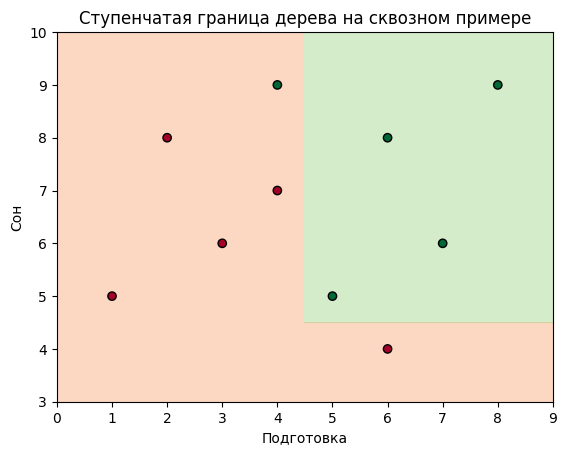

In [21]:
x1 = np.linspace(0, 9, 200)
x2 = np.linspace(3, 10, 200)
xx1, xx2 = np.meshgrid(x1, x2)
grid = pd.DataFrame({'подготовка': xx1.ravel(), 'сон': xx2.ravel()})
surface = tree.predict_proba(grid)[:, 1].reshape(xx1.shape)
plt.contourf(xx1, xx2, surface, levels=[0, 0.5, 1], cmap='RdYlGn', alpha=0.35)
plt.scatter(X['подготовка'], X['сон'], c=y, cmap='RdYlGn', edgecolor='black')
plt.xlabel('Подготовка')
plt.ylabel('Сон')
plt.title('Ступенчатая граница дерева на сквозном примере')
plt.show()


## 11. Переобучение, гиперпараметры и обрезка

**Симптом переобучения:** глубокое дерево выделяет лист почти под каждый объект train. Train-accuracy → 1.0, validation не растёт.

**Ограничение роста:**
- `max_depth` — максимальная глубина; **`None`** = без ограничения (дерево растёт, пока узлы не станут чистыми или не сработают другие стоп-правила);
- `min_samples_split` — минимум объектов для нового разбиения;
- `min_samples_leaf` — минимум объектов в листе.

**Post-pruning:** полное дерево + `ccp_alpha` — чем больше, тем сильнее обрезка.

Ниже — **другой** датасет (`make_moons`), чтобы наглядно показать переобучение. Цикл обучает деревья с `max_depth = 1, 3, 6, None` и печатает accuracy на train и validation.

In [22]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Xm, ym = make_moons(n_samples=350, noise=0.3, random_state=42)
Xt, Xv, yt, yv = train_test_split(Xm, ym, test_size=0.35, stratify=ym, random_state=42)

for depth in [1, 3, 6, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(Xt, yt)
    tr = accuracy_score(yt, model.predict(Xt))
    va = accuracy_score(yv, model.predict(Xv))
    label = 'без ограничения' if depth is None else depth
    print(f'max_depth={label!s:16s}  train={tr:.3f}  validation={va:.3f}')


max_depth=1                 train=0.824  validation=0.732
max_depth=3                 train=0.899  validation=0.862
max_depth=6                 train=0.982  validation=0.870
max_depth=без ограничения   train=1.000  validation=0.870


In [23]:
for alpha in [0.0, 0.005, 0.02, 0.08]:
    pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42).fit(Xt, yt)
    print(
        f'ccp_alpha={alpha:.3f}  листьев={pruned.get_n_leaves():3d}  '
        f'глубина={pruned.get_depth()}  validation={accuracy_score(yv, pruned.predict(Xv)):.3f}'
    )


ccp_alpha=0.000  листьев= 24  глубина=9  validation=0.870
ccp_alpha=0.005  листьев= 12  глубина=5  validation=0.870
ccp_alpha=0.020  листьев=  7  глубина=5  validation=0.902
ccp_alpha=0.080  листьев=  2  глубина=1  validation=0.732


## 12. Масштаб, пропуски и категории в sklearn

**Масштабирование.** Дерево сравнивает значение с порогом, а не расстояние. `StandardScaler` обычно **не нужен**: порядок значений сохраняется.

**Пропуски (`NaN`).** В новых версиях sklearn дерево может направлять объекты с пропуском влево или вправо. Либо заполнение пропусков до обучения (занятие 27) — зафиксируйте стратегию в проекте.

**Категории.** `DecisionTreeClassifier` не принимает строки напрямую — нужен `OneHotEncoder` или ordinal encoding (занятие 27).

**Пропуск ≠ категория «неизвестно».** Это разные ситуации:

| Ситуация | Пример | Что делать |
|----------|--------|------------|
| **Пропуск** (`NaN`) | В столбце «доход» ячейка пустая — значение не записали | Подставить **медиану** по train **и** добавить столбец «доход пропущен: да/нет», чтобы модель видела, что число подставлено |
| **Категория «неизвестно»** | В «марка авто» явно указано «неизвестно» | Это обычный ответ, не пропуск. Кодируют как любую другую категорию — при one-hot появится столбец «марка = неизвестно» |

Не смешивайте: если «неизвестно» — осмысленный ярлык, не заменяйте его медианой и не кодируйте как `NaN`.

## 13. Важность признаков: impurity и permutation

**Impurity importance** (`feature_importances_`) — сумма gain по разбиениям с этим признаком. Удобно для первого взгляда, но:
- не доказывает причинность;
- завышает признаки с множеством уникальных значений;
- делится между коррелирующими признаками.

**Permutation importance** — на validation перемешивают один столбец и смотрят падение качества. Показывает, использовала ли модель признак на новых данных.

In [24]:
pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)


подготовка    0.702381
сон           0.297619
dtype: float64

In [25]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(tree, X, y, n_repeats=10, random_state=42)
pd.DataFrame(
    {'impurity': tree.feature_importances_, 'permutation': perm.importances_mean},
    index=X.columns,
)


,impurity,permutation
подготовка,0.702381,0.38
сон,0.297619,0.11


## 14. Почему одиночное дерево редко используют в продакшене

На соревнованиях и в промышленных табличных задачах **одно** глубокое дерево почти не применяют как финальную модель:

1. **Нестабильность** — небольшое изменение train меняет первый вопрос и всё дерево перестраивается.
2. **Переобучение** — без жёстких ограничений дерево запоминает шум (п. 11).
3. **Ступенчатые прогнозы** — в регрессии дерево даёт кусочно-постоянные значения; для гладких зависимостей это грубо.
4. **Есть сильнее** — random forest и градиентный бустинг (следующие занятия) усредняют или последовательно улучшают много деревьев и обычно точнее.

Одиночное дерево — **учебная модель** и строительный блок ансамблей, а не типичный финальный выбор для production.

## 15. Когда одно дерево всё-таки уместно

**Три частых случая:**

1. **Объяснимость для бизнеса или регулятора** — нужны явные правила «если доход < X и просрочка > Y → отказ», которые можно показать без чёрного ящика.
2. **Быстрый baseline** — за минуты построить дерево с `max_depth=3` и понять, какие признаки вообще работают, прежде чем запускать бустинг.
3. **Инсайты в аналитике** — неглубокое дерево помогает быстро найти самые важные комбинации признаков, чтобы потом использовать их в других алгоритмах.

**Плюсы:** нелинейность и **взаимодействия** признаков без ручного feature engineering; понятные правила; масштабирование обычно не нужно.

**Ограничения:** нестабильность; слабая экстраполяция за пределами train; переобучение без ограничений.

> **Главная мысль.** Дерево — один шаг «вопрос → разделение → рекурсия». Сложность ограничивают гиперпараметрами. На следующем занятии (bagging / random forest) много деревьев усредняют — правила становятся устойчивее.